In [3]:
import pandas as pd
df = pd.read_csv("../data/earthquake.csv")
df.head()


,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [4]:
df.columns

Index(['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'alert'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   str    
dtypes: float64(5), str(1)
memory usage: 61.1 KB


In [6]:
df.shape

(1300, 6)

In [7]:
df = df.drop_duplicates()


In [8]:
df.shape

(1256, 6)

In [9]:
df.isnull().sum()


magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

In [10]:
df = df.dropna()


In [11]:
df.shape

(1256, 6)

In [12]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
Index: 1256 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1256 non-null   float64
 1   depth      1256 non-null   float64
 2   cdi        1256 non-null   float64
 3   mmi        1256 non-null   float64
 4   sig        1256 non-null   float64
 5   alert      1256 non-null   str    
dtypes: float64(5), str(1)
memory usage: 68.7 KB


,magnitude,depth,cdi,mmi,sig
count,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000
mean,7.060796,51.316879,6.960191,6.917994,-10.404459
std,0.423277,105.899870,2.245138,1.363892,62.370941
min,6.500000,2.000000,0.000000,1.000000,-128.000000
25%,6.710000,12.000000,6.000000,6.000000,-55.000000
50%,6.995000,19.000000,8.000000,7.000000,-8.000000
75%,7.300000,38.000000,8.000000,8.000000,31.000000
max,8.600000,670.000000,9.000000,9.000000,127.000000


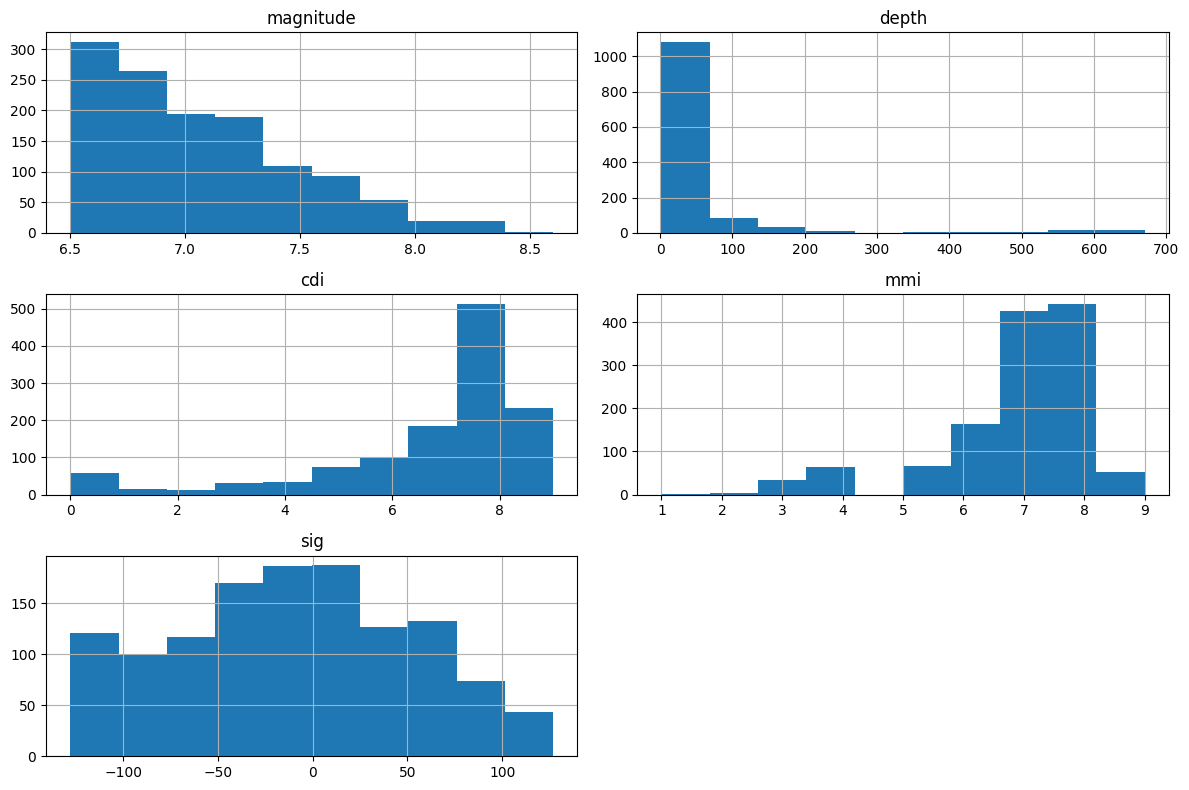

In [13]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


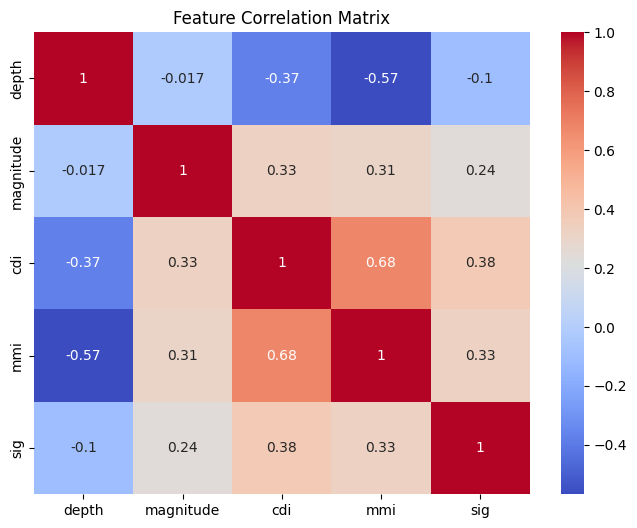

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df[['depth','magnitude','cdi','mmi','sig']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [15]:
from sklearn.preprocessing import StandardScaler

features = ['magnitude','depth','cdi','mmi','sig']

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['alert_encoded'] = le.fit_transform(df['alert'])



In [17]:
print(df[['magnitude','depth','cdi','mmi','sig']].mean())
print(df[['magnitude','depth','cdi','mmi','sig']].std())


magnitude   -4.978325e-16
depth       -2.262875e-17
cdi         -9.051500e-17
mmi         -3.620600e-16
sig         -3.394312e-17
dtype: float64
magnitude    1.000398
depth        1.000398
cdi          1.000398
mmi          1.000398
sig          1.000398
dtype: float64
